In [1]:
import requests
import numpy as np
import pandas
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.cluster import estimate_bandwidth
from sklearn.cluster import MeanShift
from sklearn.decomposition import PCA

In [2]:
#downloading
#d = requests.get("https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt")
#saving
#with open("Summary_table.txt", "wb") as f:
#    f.write(d.content)
#reading
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')
#getting column names
with open("Summary_table.txt", "r") as f:
    names = np.array([l.strip() for l in f.readlines()[1].replace("#", "").replace("\n", "").strip().split("    ") if l.strip()!=""])

In [3]:
data_GRB = pandas.DataFrame(data.T, columns=names)
data_GRB

,GRB_name,GRB_name_Fermi,T0,ra,decl,pos_error,T90,T90_error,T90_start,fluence,fluence_error,redshift,'T100',GBM_located,mjd (T0)
0,GRB260808C,GRB260808683,16:24:13.539,214.1900,34.0700,9.499364,0.6560,0.2080,16:24:13.539,6.4934e-08,8.4026e-09,-999,0.6560,True,61260.68349003
1,GRB260808A,GRB260808119,2:51:35.655,341.8400,14.0800,2.946942,23.5520,1.2800,2:51:35.655,6.3544e-06,2.8392e-08,-999,23.5520,True,61260.11916267
2,GRB260805B*,GRB260805484,11:36:36.171,259.4200,64.5900,2.771681,35.3290,1.4930,11:36:36.171,7.2886e-06,3.3788e-08,-999,35.3290,True,61257.48375198
3,GRB260805A*,GRB260805388,9:18:32.896,252.5342,34.9261,3.637119,11.9680,0.5720,9:18:32.896,2.5170e-06,2.3551e-08,-999,11.9680,True,61257.38788074
4,GRB260804A,GRB260804130,3:07:09,93.8300,18.0400,3.618697,19.2640,0.5160,3:07:09.061,3.4851e-06,2.4767e-08,-999,19.3250,True,61256.12996528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9179,GRB910425B*,None,5:33:13.716,335.9500,25.7667,4.790000,430.0160,1.0940,5:33:13.716,1.3510e-06,6.3429e-08,-999,430.0160,False,48371.23140875
9180,GRB910425A*,None,0:37:45.700,91.3000,-22.7667,1.020000,90.1760,0.2860,0:37:49.924,1.3277e-05,6.8674e-08,-999,94.4000,False,48371.02622338
9181,GRB910424A*,None,19:43:25.064,201.3000,-45.4167,13.780000,3.1360,0.5900,19:43:25.064,2.4858e-08,1.0496e-08,-999,3.1360,False,48370.82181787
9182,GRB910423A*,None,19:51:15.804,193.4750,-8.3833,11.100000,208.5760,1.1180,19:51:15.804,1.6510e-07,1.7015e-08,-999,208.5760,False,48369.82726625


In [4]:
#correcting types
data_GRB = data_GRB.astype({"GRB_name": "string", "GRB_name_Fermi": "string", "ra": "float64", "decl": "float64", "pos_error": "float64", "T90": "float64", "T90_error": "float64", "fluence": "float64", "fluence_error": "float64", "redshift": "float64", "'T100'": "float64", "GBM_located": "bool", "mjd (T0)": "float64"})

#replacing with NaNs so that the plot doesn't read them
data_GRB = data_GRB.replace(-999, np.nan)

# exploring T100

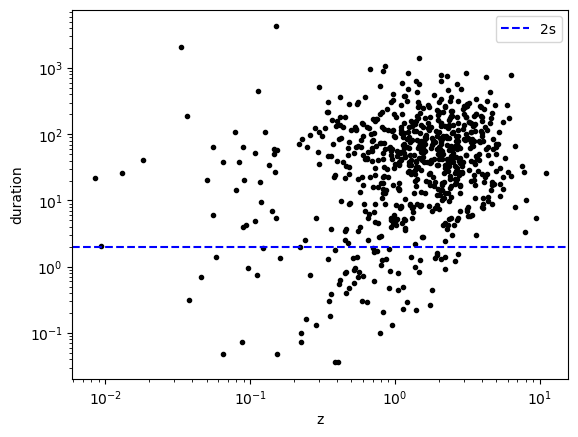

In [5]:
plt.plot(data_GRB["redshift"], data_GRB["'T100'"], ".k")
plt.xlabel("z")
plt.ylabel("duration")
plt.xscale("log")
plt.yscale("log")
plt.axhline(2, ls="--", color="b", label="2s")
plt.legend()

T100: "Total time during which the GRB was observed", plotted with respect to redshift

expecting to see 2 populations (long and short GRBs) in T100, distributed along redshift (selection effects...)

## KMeans

In [6]:
#selecting the measurements which are present in both (the not NaNs)
z = data_GRB["redshift"][~np.isnan(data_GRB["redshift"]) & ~np.isnan(data_GRB["'T100'"])]
t = data_GRB["'T100'"][~np.isnan(data_GRB["redshift"]) & ~np.isnan(data_GRB["'T100'"])]

X = np.array([z, t]).T
#scaling to mean and unit variance
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

N_c = 2
clus = KMeans(n_clusters=N_c, n_init="auto")
clus.fit(X_scaled)
centres = scaler.inverse_transform(clus.cluster_centers_)
labels = clus.predict(X_scaled)

C:\Users\giuli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


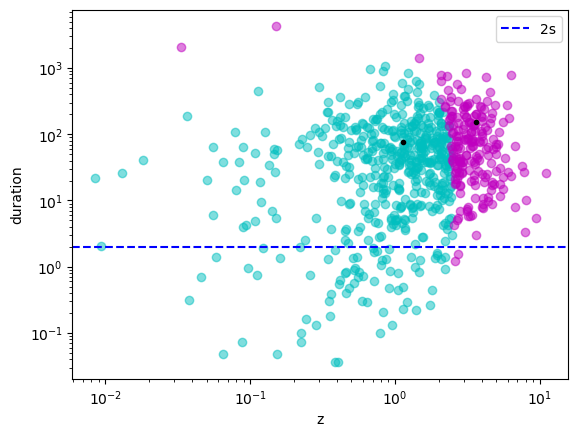

In [7]:
c = ["c", "m"]
for i in range(N_c):
    plt.scatter(X[labels==i, 0], X[labels==i, 1], color=c[i], alpha=0.5)
plt.plot(centres[:, 0], centres[:, 1], ".k")
plt.xlabel("z")
plt.ylabel("duration")
plt.xscale("log")
plt.yscale("log")
plt.axhline(2, ls="--", color="b", label="2s")
plt.legend()

not as expected... maybe Kmeans was forced to find 2 clusters

trying with:

## MeanShift

In [8]:
width = estimate_bandwidth(X_scaled)
MS = MeanShift(bandwidth=width)
MS.fit(X_scaled)

labels_MS = MS.labels_
N_labels_MS = np.unique(MS.labels_)
N_labels_MS = N_labels_MS[N_labels_MS>=0]
N_c_MS = len(N_labels_MS)
print(N_c_MS, "estimated clusters")
centres_MS = scaler.inverse_transform(MS.cluster_centers_)

11 estimated clusters


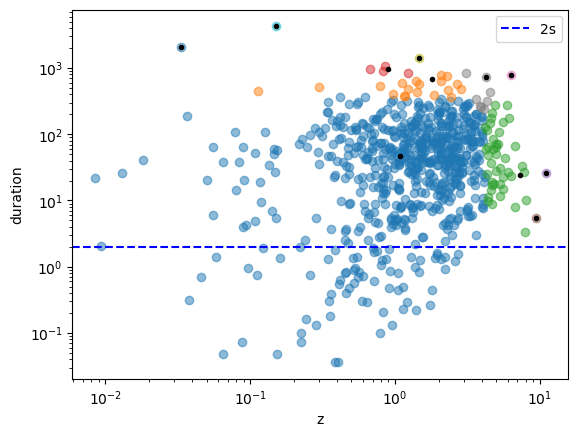

In [9]:
for i in range(N_c_MS):
    plt.scatter(X[labels_MS==i, 0], X[labels_MS==i, 1], alpha=0.5)
plt.plot(centres_MS[:, 0], centres_MS[:, 1], ".k")
plt.xlabel("z")
plt.ylabel("duration")
plt.xscale("log")
plt.yscale("log")
plt.axhline(2, ls="--", color="b", label="2s")
plt.legend()

guess there aren't two distinctly divided subpopulations, maybe they're affected by outliers

# looking at 3D distribution

Text(0.5, 0, 'z')

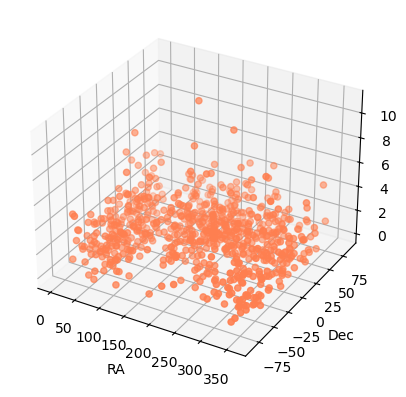

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.scatter(data_GRB["ra"], data_GRB["decl"], data_GRB["redshift"], color="coral")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_zlabel("z")

## PCA

In [11]:
RA = data_GRB["ra"][~np.isnan(data_GRB["ra"]) & ~np.isnan(data_GRB["decl"]) & ~np.isnan(data_GRB["redshift"])]
Dec = data_GRB["decl"][~np.isnan(data_GRB["ra"]) & ~np.isnan(data_GRB["decl"]) & ~np.isnan(data_GRB["redshift"])]
z = data_GRB["redshift"][~np.isnan(data_GRB["ra"]) & ~np.isnan(data_GRB["decl"]) & ~np.isnan(data_GRB["redshift"])]

X = np.array([RA, Dec, z]).T

pca = PCA(n_components=2)
pca.fit(X)
X_reduced = pca.transform(X)

Text(0, 0.5, 'Eigenvalue 2')

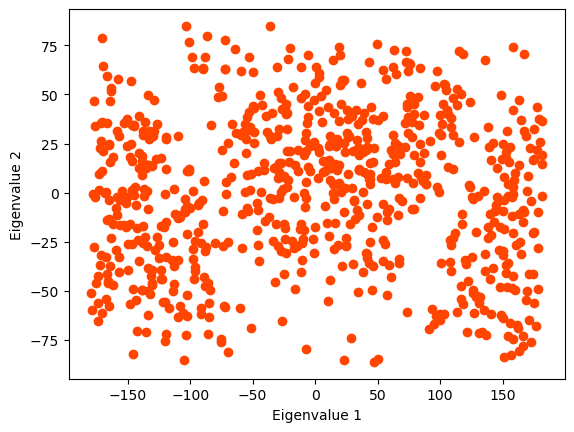

In [12]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], color="orangered")
plt.xlabel("Eigenvalue 1")
plt.ylabel("Eigenvalue 2")

there seem to be 3 clusters!

## KMeans

In [13]:
N_clusters = 3 #by eye
clust = KMeans(N_clusters, n_init="auto")
clust.fit(X_reduced)
labels_s = clust.predict(X_reduced)
centres_3D = clust.cluster_centers_

C:\Users\giuli\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Text(0, 0.5, 'Eigenvalue 2')

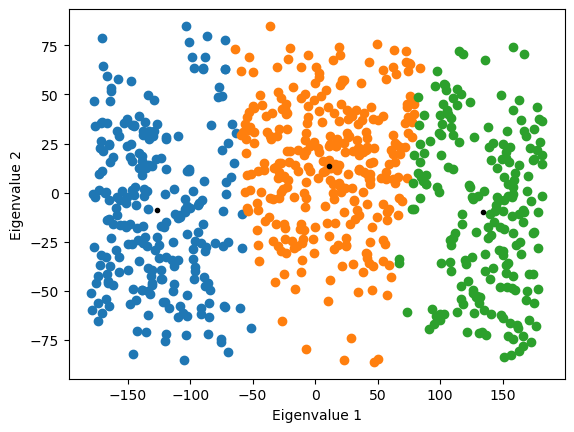

In [14]:
for i in range(N_clusters):
    plt.scatter(X_reduced[labels_s==i, 0], X_reduced[labels_s==i, 1])
plt.plot(centres_3D[:, 0], centres_3D[:, 1], ".k")
plt.xlabel("Eigenvalue 1")
plt.ylabel("Eigenvalue 2")

as expected

Text(0.5, 0, 'z')

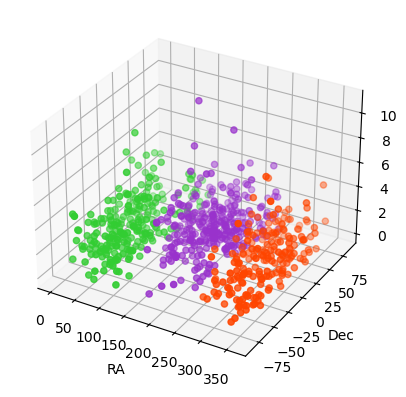

In [15]:
colours = ["limegreen", "darkorchid", "orangered"]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

for i in range(N_clusters):
    ax.scatter(X[labels_s==i, 0], X[labels_s==i, 1], X[labels_s==i, 2], color=colours[i])

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_zlabel("z")

maybe there were sources in between and they had to divide the observations in 3 patches